In [26]:
#Import block: 
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

import pandas as pd

from iminuit import Minuit, cost

from scipy import stats, interpolate
from scipy.interpolate import interp1d, CubicSpline, PchipInterpolator
from scipy.integrate import quad

## Problem 5: Exam in Advanced Methods in Applied Statistics
Author: Aske Roelshøj

KU-ID: KVF851

Date(s): Thurs. March 26 to Fri. March 27, 2026

## 5a

In [27]:
data = np.array([[ 203.41 , -89.37 ],
                [ 203.435, -94.88 ],
                [ 203.46 , -101.25 ],
                [ 203.484, -106.52 ],
                [ 203.509, -108.66 ],
                [ 203.534, -114.25 ],
                [ 203.558, -114.30 ],
                [ 203.583, -117.66 ],
                [ 203.608, -122.45 ]])
#col 1 is sol, col 2 is temp

sol = data[:,0]
temp = data[:,1]
temp_unc = 0.001*np.ones_like(temp)

In [28]:
#Linear spline: 
x_vals = np.linspace(sol.min(), sol.max(), 200)
lin_spline = np.interp(x_vals, sol, temp)
#Cubic spline:
chip_spline_func =PchipInterpolator(sol, temp)
chip_spline = chip_spline_func(x_vals)

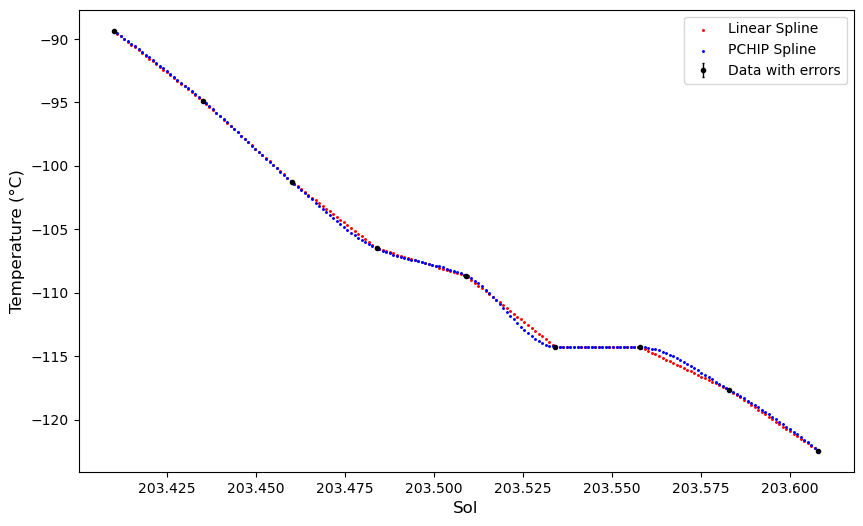

In [29]:
#Plot the results: 
fig, ax = plt.subplots(figsize=(10,6))
ax.errorbar(sol, temp, yerr=temp_unc, fmt='.k', ecolor='k', elinewidth=1, capsize=1, capthick=1, label = 'Data with errors')
ax.scatter(x_vals, lin_spline, marker = '.', label='Linear Spline', color = 'r', s= 5)
ax.scatter(x_vals, chip_spline, marker = '.', label='PCHIP Spline', color = 'b', s= 5)
ax.set_xlabel('Sol', fontsize=12)
ax.set_ylabel('Temperature (°C)', fontsize=12)
ax.legend();

In [30]:
sol_target = 203.570
temp_lin_target = np.interp(sol_target, sol, temp)
temp_PCHIP_target = chip_spline_func(sol_target)
print(f"Temperature at sol {sol_target} using linear spline: {temp_lin_target:.2f} °C")
print(f"Temperature at sol {sol_target} using PCHIP spline: {temp_PCHIP_target:.2f} °C")

#Summarize in df and print latex: 
results_df = pd.DataFrame({
    'Method': ['Linear Spline', 'PCHIP Spline'],
    'Temperature at Sol 203.570 (°C)': [temp_lin_target, temp_PCHIP_target]
})
print(results_df.to_latex(index=False))

Temperature at sol 203.57 using linear spline: -115.91 °C
Temperature at sol 203.57 using PCHIP spline: -115.42 °C
\begin{tabular}{ll}
\toprule
Method & Temperature at Sol 203.570 (°C) \\
\midrule
Linear Spline & -115.912800 \\
PCHIP Spline & -115.41929294830744 \\
\bottomrule
\end{tabular}



## 5b

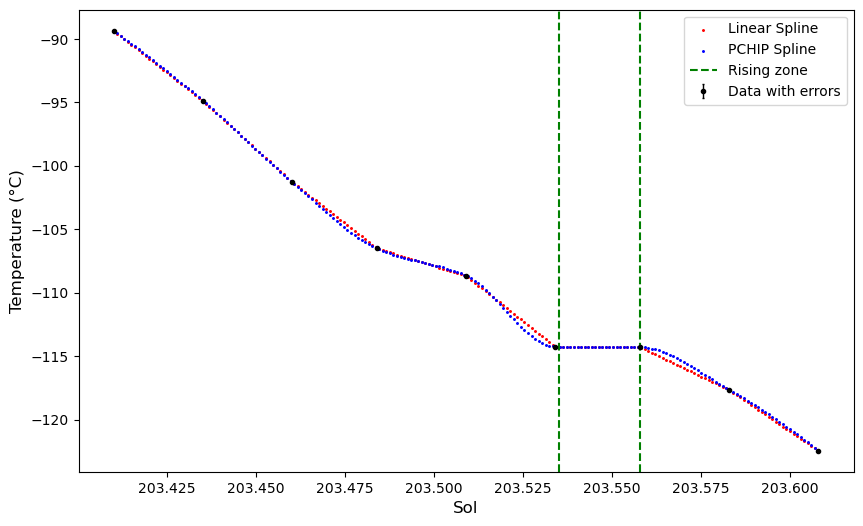

In [31]:
low_sol = 203.41
high_sol = 203.608
sol_range = np.linspace(low_sol, high_sol, 200)
lin_spline_range = np.interp(sol_range, sol, temp)
chip_spline_range = chip_spline_func(sol_range)

fig, ax = plt.subplots(figsize=(10,6))
ax.errorbar(sol, temp, yerr=temp_unc, fmt='.k', ecolor='k', elinewidth=1, capsize=1, capthick=1, label = 'Data with errors')
ax.scatter(sol_range, lin_spline_range, marker = '.', label='Linear Spline', color = 'r', s= 5)
ax.scatter(sol_range, chip_spline_range, marker = '.', label='PCHIP Spline', color = 'b', s= 5)
ax.axvline(203.535, color='g', linestyle='--', label=f'Rising zone')
ax.axvline(203.558, color='g', linestyle='--')
ax.set_xlabel('Sol', fontsize=12)
ax.set_ylabel('Temperature (°C)', fontsize=12)
ax.legend();


## 5c

In [32]:
tol = 0.09
stepsize = 0.0004

#Find derivative of PCHIP spline:
chip_spline_derivative = chip_spline_func.derivative()
#Find the sol value where the derivative is steepest (max absolute value):
derivative_PCHIP = np.max(np.abs(chip_spline_derivative(sol_range)))*0.0004
#Find the x-value corresponding to the max_derivative:
sol_val_chip = sol_range[np.argmax(np.abs(chip_spline_derivative(sol_range)))]
print(f"Steepest point for PCHIP spline: Sol = {sol_val_chip:.6f}, Derivative = {derivative_PCHIP:.6f}")

#Find the derivative of the linear spline:
lin_spline_derivative = np.gradient(lin_spline_range, sol_range)
#Find the sol value where the derivative is steepest (max absolute value):
derivative_lin = np.max(np.abs(lin_spline_derivative))*0.0004
#Find the x-value corresponding to the max_derivative:
sol_val_lin = sol_range[np.argmax(np.abs(lin_spline_derivative))]
print(f"Steepest point for Linear spline: Sol = {sol_val_lin:.6f}, Derivative = {derivative_lin:.6f}")

#Summarize in df and print latex:
steepest_df = pd.DataFrame({
    'Method': ['Linear Spline', 'PCHIP Spline'],
    'Steepest Sol': [sol_val_lin, sol_val_chip],
    'Max Derivative': [derivative_lin, derivative_PCHIP]
})
print(steepest_df.to_latex(index=False))

Steepest point for PCHIP spline: Sol = 203.519447, Derivative = 0.122718
Steepest point for Linear spline: Sol = 203.451789, Derivative = 0.101920
\begin{tabular}{lrr}
\toprule
Method & Steepest Sol & Max Derivative \\
\midrule
Linear Spline & 203.451789 & 0.101920 \\
PCHIP Spline & 203.519447 & 0.122718 \\
\bottomrule
\end{tabular}



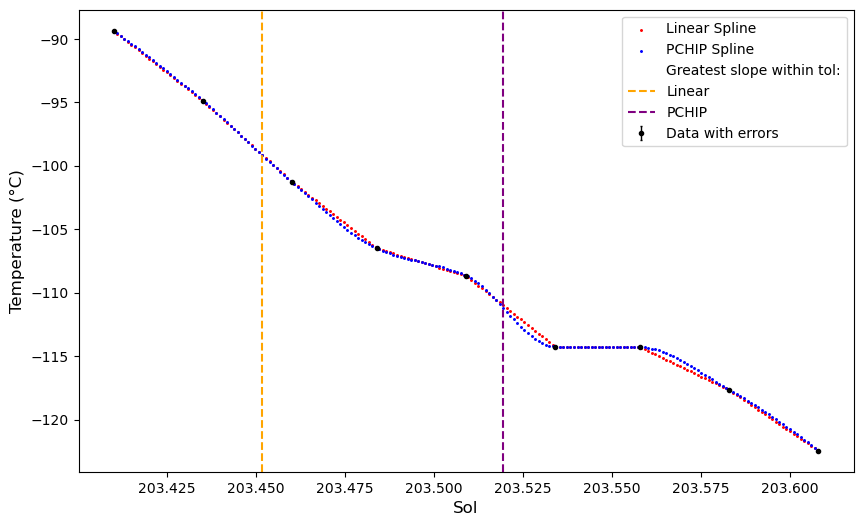

In [33]:
fig, ax = plt.subplots(figsize=(10,6))
ax.errorbar(sol, temp, yerr=temp_unc, fmt='.k', ecolor='k', elinewidth=1, capsize=1, capthick=1, label = 'Data with errors')
ax.scatter(sol_range, lin_spline_range, marker = '.', label='Linear Spline', color = 'r', s= 5)
ax.scatter(sol_range, chip_spline_range, marker = '.', label='PCHIP Spline', color = 'b', s= 5)
ax.plot([], [], alpha =0, label = f'Greatest slope within tol:')
ax.axvline(sol_val_lin, color='orange', linestyle='--', label=f'Linear')
ax.axvline(sol_val_chip, color='purple', linestyle='--', label=f'PCHIP')
ax.set_xlabel('Sol', fontsize=12)
ax.set_ylabel('Temperature (°C)', fontsize=12)
ax.legend();